# Mass models and rotation curves

The heart of a black-hole mass measurement is the mapping from a mass model
to a circular-velocity curve. This tutorial opens that box:

1. the **MGE velocity engine** (`MGEVelocityIntr`) that computes exact
   circular velocities for any Multi-Gaussian Expansion plus black hole;
2. the **analytic profile wrappers** (`SersicMGE`, `NukerMGE`,
   `CoreSersicMGE`) that let samplers work in natural profile parameters;
3. **composite models** — adding the gas disk's self-gravity with
   `GasSelfGrav` and `QuadratureVelocitySum`;
4. what the **black hole's sphere of influence** looks like in velocity space.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from supermage.simulators.velocity_models import (
    MGEVelocityIntr, SersicMGE, NukerMGE, CoreSersicMGE,
    GasSelfGrav, QuadratureVelocitySum,
    sersic_profile_torch_1d, nuker_profile_torch_1d, core_sersic_torch_1d,
)
from supermage.simulators.intensity_models import ExponentialDisk2D

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float32

R = torch.logspace(0, 4.2, 400, device=device, dtype=dtype)   # 1 pc .. ~16 kpc
R_np = R.cpu().numpy()

def flat_theta(model, values):
    "Assemble the flat parameter tensor in the model's dynamic_params order."
    out = []
    for p in model.dynamic_params:
        v = values[p.name]
        out.extend(v if isinstance(v, (list, tuple)) else [v])
    return torch.tensor(out, device=device, dtype=dtype)

## 1. The MGE engine directly

A Multi-Gaussian Expansion describes an axisymmetric density as a sum of
concentric Gaussians, each with a peak surface density `surf`, a dispersion
`sigma` [pc] and an intrinsic axial ratio `qintr`. `MGEVelocityIntr`
evaluates the classic Cappellari (2002) quadrature for the circular
velocity — with a double-exponential transform so the improper integral is
accurate even in float32 — and adds a (softened) Keplerian black hole.

Here is a toy three-Gaussian galaxy:

parameters: ['surf', 'sigma', 'qintr', 'M_to_L', 'm_bh', 'inc']


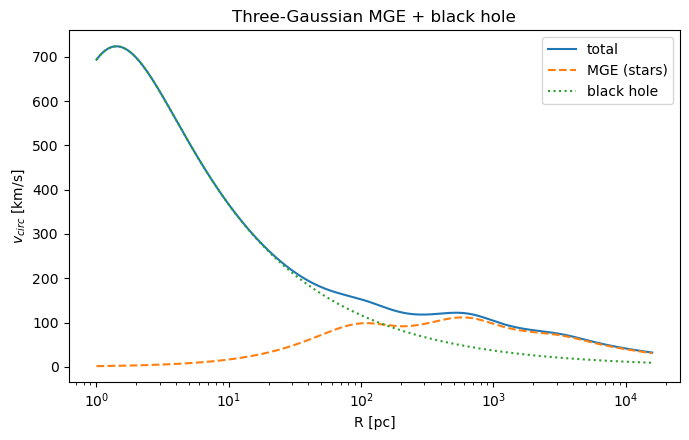

In [2]:
mge = MGEVelocityIntr(N_components=3, device=device, dtype=dtype, soft=1.0)
print("parameters:", [p.name for p in mge.dynamic_params])

mge_pars = {
    "surf":   [5e3, 1e3, 50.0],     # peak surface brightness [L_sun/pc^2]
    "sigma":  [50.0, 300.0, 1500.0],# Gaussian dispersions [pc]
    "qintr":  [0.6, 0.6, 0.6],      # intrinsic flattening
    "M_to_L": 4.0,                  # mass-to-light ratio
    "m_bh":   8.5,                  # log10(M_BH / M_sun)
    "inc":    np.deg2rad(60.0),
}

v_tot = mge.velocity(flat_theta(mge, mge_pars), R_map=R)

pars_nobh = dict(mge_pars, m_bh=-10.0)
v_stars = mge.velocity(flat_theta(mge, pars_nobh), R_map=R)

pars_bh_only = dict(mge_pars, M_to_L=0.0)
v_bh = mge.velocity(flat_theta(mge, pars_bh_only), R_map=R)

plt.figure(figsize=(7, 4.5))
plt.plot(R_np, v_tot.detach().cpu(), label="total")
plt.plot(R_np, v_stars.detach().cpu(), "--", label="MGE (stars)")
plt.plot(R_np, v_bh.detach().cpu(), ":", label="black hole")
plt.xscale("log"); plt.xlabel("R [pc]"); plt.ylabel("$v_{circ}$ [km/s]")
plt.title("Three-Gaussian MGE + black hole")
plt.legend(); plt.tight_layout(); plt.show()

## 2. Analytic stellar profiles

Sampling raw per-Gaussian amplitudes is awkward: they are many, degenerate,
and un-physical to put priors on. SuperMAGE instead parameterizes the
stellar surface-brightness profile *analytically* and converts it to an MGE
on the fly. The three built-in families:

| Profile | Function | Typical use |
|---|---|---|
| Sérsic | `sersic_profile_torch_1d` | ordinary bulges/ellipticals |
| Nuker | `nuker_profile_torch_1d` | nuclear double power laws |
| Core-Sérsic | `core_sersic_torch_1d` | core ellipticals (depleted centres) |

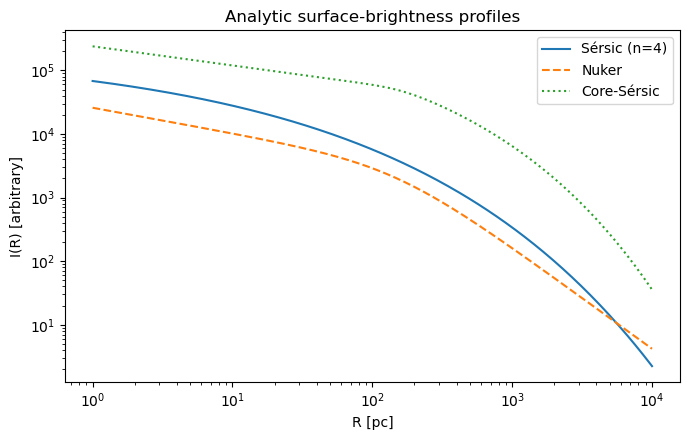

In [3]:
r_prof = torch.logspace(0, 4, 300, device=device, dtype=dtype)

I_sersic = sersic_profile_torch_1d(r_prof, I_e=torch.tensor(1.0e2, device=device),
                                   R_e=torch.tensor(2000.0, device=device),
                                   n=torch.tensor(4.0, device=device))
I_nuker = nuker_profile_torch_1d(r_prof, I_b=torch.tensor(2.0e3, device=device),
                                 r_b=torch.tensor(150.0, device=device),
                                 alpha=torch.tensor(1.5, device=device),
                                 beta=torch.tensor(1.6, device=device),
                                 gamma=torch.tensor(0.4, device=device))
I_coreser = core_sersic_torch_1d(r_prof, I_b=torch.tensor(2.0e3, device=device),
                                 R_b=torch.tensor(150.0, device=device),
                                 R_e=torch.tensor(2000.0, device=device),
                                 alpha=torch.tensor(5.0, device=device),
                                 gamma=torch.tensor(0.3, device=device),
                                 n=torch.tensor(3.0, device=device))

plt.figure(figsize=(7, 4.5))
r_ = r_prof.cpu().numpy()
plt.plot(r_, I_sersic.cpu(), label="Sérsic (n=4)")
plt.plot(r_, I_nuker.cpu(), "--", label="Nuker")
plt.plot(r_, I_coreser.cpu(), ":", label="Core-Sérsic")
plt.xscale("log"); plt.yscale("log")
plt.xlabel("R [pc]"); plt.ylabel("I(R) [arbitrary]")
plt.title("Analytic surface-brightness profiles")
plt.legend(); plt.tight_layout(); plt.show()

```{note}
`core_sersic_torch_1d` is evaluated in **log-space** internally. The naive
algebraic form builds `R_e**alpha`, which overflows float32 for large
effective radii and used to manufacture a spurious "extended" likelihood
mode in nested-sampling fits. The log-space form is mathematically
identical and finite everywhere.
```

## 3. Profile → MGE: the precomputed projector

Each wrapper owns a `PrecomputedMGEProjector`: a fixed Gaussian basis `A`
on a log radius grid, with the ridge-regularized least-squares projector
`P = (AᵀA + λI)⁻¹Aᵀ` factored **once** at construction. Converting a
profile to MGE amplitudes is then a single matmul per likelihood call —
differentiable and essentially free.

How faithful is the projection? Reconstruct the profile from its MGE:

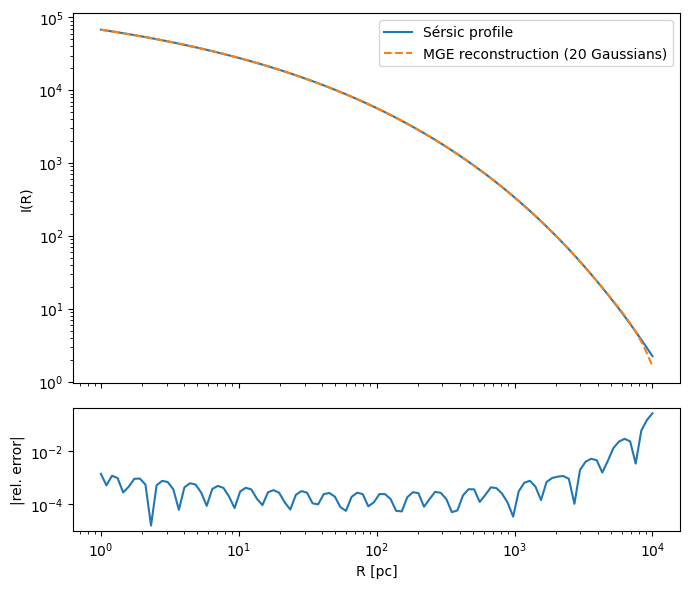

max relative error: 2.75e-01


In [4]:
stars = SersicMGE(N_MGE_components=20, distance_Mpc=16.5, soft=1.0,
                  device=device, dtype=dtype)
proj = stars.projector

y = sersic_profile_torch_1d(proj.r_grid,
                            I_e=torch.tensor(100.0, device=device),
                            R_e=torch.tensor(2000.0, device=device),
                            n=torch.tensor(4.0, device=device))
surf  = proj.surf_from_profile(y)
recon = proj.profile_from_surf(surf)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), sharex=True,
                               height_ratios=[3, 1])
rg = proj.r_grid.cpu().numpy()
ax1.plot(rg, y.cpu(), label="Sérsic profile")
ax1.plot(rg, recon.cpu(), "--", label="MGE reconstruction (20 Gaussians)")
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.set_ylabel("I(R)"); ax1.legend()
ax2.plot(rg, (recon / y - 1).abs().cpu())
ax2.set_xscale("log"); ax2.set_yscale("log")
ax2.set_xlabel("R [pc]"); ax2.set_ylabel("|rel. error|")
plt.tight_layout(); plt.show()
print(f"max relative error: {float((recon / y - 1).abs().max()):.2e}")

```{note}
The reconstruction is accurate to ~10⁻⁴ across the fitted range; the error grows only at the very outer edge of the radius grid (`r_max_pc`), where the truncated Gaussian basis rolls off faster than the profile. Choose `r_min_pc`/`r_max_pc` so the region your data constrains sits well inside the grid.
```

## 4. The wrappers: same engine, natural parameters

`SersicMGE`, `NukerMGE` and `CoreSersicMGE` expose the profile parameters
(radii in **arcsec**, intensities as **log10**) plus the shared galaxy
parameters `inc`, `qintr` and `m_bh`. Compare the rotation curves of the
three families from section 2 (radii converted with the model distance,
16.5 Mpc ⇒ ≈ 80 pc/arcsec):

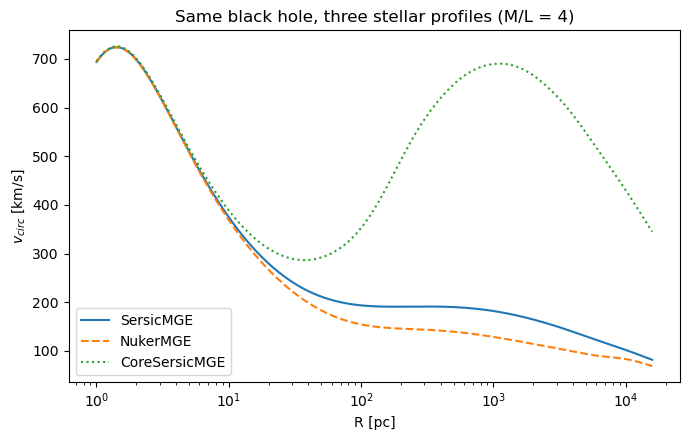

In [5]:
nuker = NukerMGE(N_MGE_components=20, distance_Mpc=16.5, soft=1.0,
                 device=device, dtype=dtype)
coreser = CoreSersicMGE(N_MGE_components=20, distance_Mpc=16.5, soft=1.0,
                        device=device, dtype=dtype)

common = {"inc": np.deg2rad(60.0), "qintr": 0.6, "m_bh": 8.5}
pc_per_arcsec = float(stars.pc_per_arcsec)

v_sersic = stars.velocity(flat_theta(stars, {
    **common, "n": 4.0, "r_e": 2000.0 / pc_per_arcsec, "intensity_r_e": np.log10(4 * 100.0),
}), R_flat=R)
v_nuker = nuker.velocity(flat_theta(nuker, {
    **common, "alpha": 1.5, "gamma_minus_beta": 0.4 - 1.6, "gamma": 0.4,
    "r_b": 150.0 / pc_per_arcsec, "intensity_r_b": np.log10(4 * 2.0e3),
}), R_flat=R)
v_coreser = coreser.velocity(flat_theta(coreser, {
    **common, "I_b": np.log10(4 * 2.0e3), "R_b": 150.0 / pc_per_arcsec,
    "R_e": 2000.0 / pc_per_arcsec, "alpha": 5.0, "gamma": 0.3, "n": 3.0,
}), R_flat=R)

plt.figure(figsize=(7, 4.5))
plt.plot(R_np, v_sersic.detach().cpu(), label="SersicMGE")
plt.plot(R_np, v_nuker.detach().cpu(), "--", label="NukerMGE")
plt.plot(R_np, v_coreser.detach().cpu(), ":", label="CoreSersicMGE")
plt.xscale("log"); plt.xlabel("R [pc]"); plt.ylabel("$v_{circ}$ [km/s]")
plt.title("Same black hole, three stellar profiles (M/L = 4)")
plt.legend(); plt.tight_layout(); plt.show()

(The `M/L` of the wrappers is fixed to 1 internally — the log-intensity
normalization carries the mass scale, which is why we folded a factor of 4
into the intensities above.)

## 5. Adding the gas disk: composite mass models

Cold gas disks are not always negligible. `GasSelfGrav` implements the
razor-thin exponential-disk rotation curve (Freeman 1970) and **shares its
scale length with the intensity model**, so photometry and dynamics stay
consistent. `QuadratureVelocitySum` composes any set of mass components as
`v² = Σᵢ vᵢ²` and automatically shares a single inclination among the
components that need one.

In [6]:
disk_intensity = ExponentialDisk2D()
gas   = GasSelfGrav(disk_intensity, device, dtype)
stars2 = SersicMGE(N_MGE_components=20, distance_Mpc=16.5, soft=1.0,
                   device=device, dtype=dtype)
total = QuadratureVelocitySum((stars2, gas))
print("composite parameters:", [p.name for p in total.dynamic_params])

composite parameters: ['qintr', 'm_bh', 'n', 'r_e', 'intensity_r_e', 'scale', 'm_gas', 'inclination']


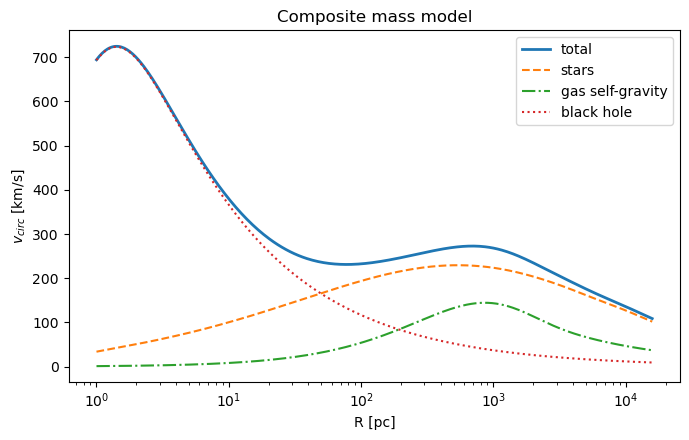

In [7]:
comp = {
    "inclination": np.deg2rad(60.0), "qintr": 0.6,
    "m_bh": 8.5, "n": 4.0, "r_e": 25.0, "intensity_r_e": 2.8,
    "m_gas": 9.7,      # log10(M_gas / M_sun)
    "scale": 400.0,    # gas disk scale length [pc]
}
v_total = total.velocity(flat_theta(total, comp), R_flat=R)

# individual pieces for the plot
v_stars_only = total.velocity(flat_theta(total, dict(comp, m_gas=-10.0, m_bh=-10.0)), R_flat=R)
v_gas_only   = total.velocity(flat_theta(total, dict(comp, intensity_r_e=-10.0, m_bh=-10.0)), R_flat=R)
v_bh_only    = total.velocity(flat_theta(total, dict(comp, intensity_r_e=-10.0, m_gas=-10.0)), R_flat=R)

plt.figure(figsize=(7, 4.5))
plt.plot(R_np, v_total.detach().cpu(), label="total", lw=2)
plt.plot(R_np, v_stars_only.detach().cpu(), "--", label="stars")
plt.plot(R_np, v_gas_only.detach().cpu(), "-.", label="gas self-gravity")
plt.plot(R_np, v_bh_only.detach().cpu(), ":", label="black hole")
plt.xscale("log"); plt.xlabel("R [pc]"); plt.ylabel("$v_{circ}$ [km/s]")
plt.title("Composite mass model")
plt.legend(); plt.tight_layout(); plt.show()

## 6. The sphere of influence

The black hole dominates the potential inside
$R_\mathrm{SOI} \approx G M_\bullet / \sigma_\star^2$. A useful visual
check before designing an observation: sweep the black-hole mass and see
where the curves separate. Data must resolve (in angle *and* in velocity)
the region where your candidate masses actually differ.

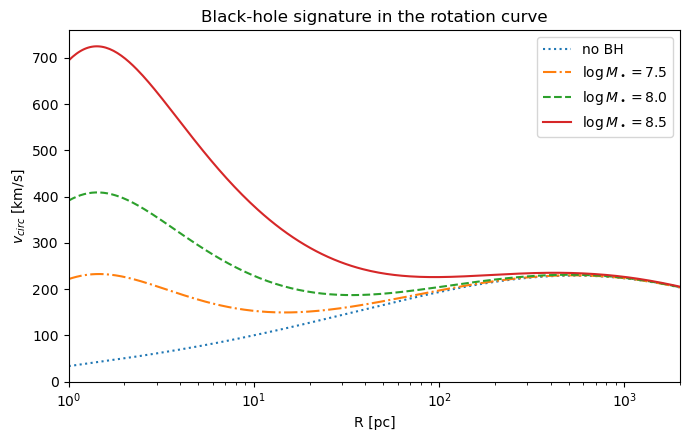

In [8]:
plt.figure(figsize=(7, 4.5))
for mbh, style in [(-10.0, ":"), (7.5, "-."), (8.0, "--"), (8.5, "-")]:
    v = stars.velocity(flat_theta(stars, {
        "inc": np.deg2rad(60.0), "qintr": 0.6, "m_bh": mbh,
        "n": 4.0, "r_e": 25.0, "intensity_r_e": 2.8,
    }), R_flat=R)
    label = "no BH" if mbh < 0 else f"$\\log M_\\bullet = {mbh}$"
    plt.plot(R_np, v.detach().cpu(), style, label=label)
plt.xscale("log"); plt.xlim(1, 2e3)
plt.xlabel("R [pc]"); plt.ylabel("$v_{circ}$ [km/s]")
plt.title("Black-hole signature in the rotation curve")
plt.legend(); plt.tight_layout(); plt.show()

## Practical notes

- **Units.** Radii fed to `velocity` are in **pc**; wrapper profile radii
  are in **arcsec**; intensities are `log10`; `m_bh`/`m_gas` are
  `log10(M/M_sun)`; inclinations in radians. With the default
  `G = 0.004301` velocities come out in km/s.
- **`soft`** is the Plummer softening of the black-hole potential — set it
  to something comfortably below your resolution but nonzero (it also
  anchors the lookup table's inner edge).
- **`radius_res` and `quad_points`** trade accuracy for speed; the defaults
  (4096, 128) are conservative.
- All of these models plug directly into the renderers of the
  [getting-started tutorial](01_getting_started.ipynb) as `velocity_model`.